#### Tech Challenge - Fase 1 - Data Analysis and Exploration

**Contexto**

Atuando como Expert em Data Analytics em uma empresa que exporta vinhos do Brasil para o mundo todo em uma área recém-criada dentro da empresa sendo responsável pelos relatórios iniciais a serem apresentados, explicando a quantidade de vinhos exportados e os fatores externos que podem vir a surgir e que interferem nas análises:

1. Dados climáticos
2. Dados demográficos
3. Dados econômicos
4. Dados de avaliações de vinhos

Sendo necessario a criação de uma tabela contendo as seguintes informações:

a. País de origem (Brasil)
b. País de destino
c. Quantidade em litros de vinho exportado (utilize: 1KG =1L)
d. Valor em US$

Com os dados fornecido de vinícola parceira e que podem ser encontrados aqui através do seguinte link:

 http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01

##### Importação de pacotes, bibliotecas e criação de funções (DEF)

In [1]:
# Importar biblioteca completa
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Importar função especifica de um módulo
from datetime import datetime
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Função para identificar sequências consecutivas
def encontrar_sequencias_consecutivas(anos, min_consecutivos):
    anos = sorted(anos)
    sequencia = []
    resultado = []
    
    for ano in anos:
        if not sequencia or ano == sequencia[-1] + 1:
            sequencia.append(ano)
        else:
            if len(sequencia) >= min_consecutivos:
                resultado.append(sequencia)
            sequencia = [ano]
    
    # Checar última sequência
    if len(sequencia) >= min_consecutivos:
        resultado.append(sequencia)
    
    return resultado

##### Tratar base de dados

In [3]:
# Código original para ler o data frame, mas depois com a ajuda dos colega da Pós foi alterado conforme proxima celula

# Como o delimitador do arquivo exportado é o espaço, foi necesasrio tratar o arquivo de uma maneira diferente para garantir a criação correta do Data Frma 

# Caminho onde esta o arquivo
caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\05 - Atividade a ser entregue até 03_06 - Em grupo\Base\ExpVinho.csv"

# Lista vazia para armazenar os dados
dados = []

with open(caminho_arquivo, encoding='utf-8') as f:
    linhas = f.readlines()

# Separar o cabeçalho original
cabecalho_raw = linhas[0].strip().split()

# Definir colunas iniciais fixas
colunas = ['Id', 'País']

# Selecionar os anos
anos = cabecalho_raw[2:]

# Agrupar pares de colunas por ano como 'Ano_Quantidade' e 'Ano_Valor'
for i in range(0, len(anos), 2):
    ano = anos[i]
    colunas.append(f"{ano}_quantidade_kg")
    colunas.append(f"{ano}_valor_usd")

# Lê os dados
for linha in linhas[1:]:
    partes = linha.strip().split()
    id = partes[0]

    # Juntar os campos do país até encontrar o início dos valores (número)
    i = 1
    while not partes[i].isdigit():
        i += 1
    pais = ' '.join(partes[1:i])
    valores = partes[i:]
    dados.append([id, pais] + valores)

# Criar o DataFrame e ajustar o nome
df_vinhos = pd.DataFrame(dados, columns=colunas)
df_vinhos = df_vinhos.rename(columns={'País': 'pais','Id':'id'})
df_vinhos

,id,pais,1970_quantidade_kg,1970_valor_usd,1971_quantidade_kg,1971_valor_usd,1972_quantidade_kg,1972_valor_usd,1973_quantidade_kg,1973_valor_usd,...,2020_quantidade_kg,2020_valor_usd,2021_quantidade_kg,2021_valor_usd,2022_quantidade_kg,2022_valor_usd,2023_quantidade_kg,2023_valor_usd,2024_quantidade_kg,2024_valor_usd
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,137,Tuvalu,0,0,0,0,0,0,0,0,...,2,4,0,0,0,0,0,0,0,0
137,138,Uruguai,0,0,0,0,0,0,0,0,...,0,0,136774,149842,637117,997367,326093,454271,36729,62325
138,139,Vanuatu,0,0,0,0,0,0,0,0,...,18,31,0,0,0,0,0,0,0,0
139,140,Venezuela,0,0,3200,2000,1350,750,11700,6458,...,4086,9808,26415,35944,23220,32351,141030,220512,122922,199418


In [4]:
# Caminho do arquivo
caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\05 - Atividade a ser entregue até 03_06 - Em grupo\Base\ExpVinho.csv"

# Ler o arquivo
df_vinhos = pd.read_csv(caminho_arquivo, delimiter='\t')

# Renomear colunas 'Id' e 'País'
df_vinhos = df_vinhos.rename(columns={'Id': 'id', 'País': 'pais'})

# Função para renomear colunas de anos
def renomear_coluna(col):
    try:
        ano = int(float(col))
        if '.' in str(col):
            return f"{ano}_valor_usd"
        else:
            return f"{ano}_quantidade_kg"
    except ValueError:
        return col.lower()

# Aplicar a função nas colunas
df_vinhos.columns = [renomear_coluna(col) for col in df_vinhos.columns]

# Exibir o DataFrame
df_vinhos

,id,pais,1970_quantidade_kg,1970_valor_usd,1971_quantidade_kg,1971_valor_usd,1972_quantidade_kg,1972_valor_usd,1973_quantidade_kg,1973_valor_usd,...,2020_quantidade_kg,2020_valor_usd,2021_quantidade_kg,2021_valor_usd,2022_quantidade_kg,2022_valor_usd,2023_quantidade_kg,2023_valor_usd,2024_quantidade_kg,2024_valor_usd
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,137,Tuvalu,0,0,0,0,0,0,0,0,...,2,4,0,0,0,0,0,0,0,0
137,138,Uruguai,0,0,0,0,0,0,0,0,...,0,0,136774,149842,637117,997367,326093,454271,36729,62325
138,139,Vanuatu,0,0,0,0,0,0,0,0,...,18,31,0,0,0,0,0,0,0,0
139,140,Venezuela,0,0,3200,2000,1350,750,11700,6458,...,4086,9808,26415,35944,23220,32351,141030,220512,122922,199418


In [5]:
# Despitovar e Pivotar a tabela, saindo de um modelo largo para um modelo longo

# Selecionar o nome das colunas
anos = df_vinhos.columns[2:]
anos

# Fazer um copia do data frame
df_vinhos_tratado = df_vinhos.copy() # Utilizando o .copy para copiar os dados do Data Frame e dessa forma, não precisar executar toda vez o notebook inteiro 

# Despivotar o data frame
df_vinhos_tratado = df_vinhos.melt(id_vars=['id','pais'],value_vars=anos, var_name='ano_tipo', value_name='valor') 

# Criar duas novas coluna com o ano e o tipo
df_vinhos_tratado['tipo'] = df_vinhos_tratado['ano_tipo'].str.split('_', n=1).str[1]
df_vinhos_tratado['ano'] = df_vinhos_tratado['ano_tipo'].str.split('_', n=1).str[0]

# Remover coluna não necessaria
df_vinhos_tratado = df_vinhos_tratado.drop(columns=['ano_tipo'])

# Pivotar a coluna tipo com o valor 
df_vinhos_tratado = df_vinhos_tratado.pivot(index=['id', 'pais', 'ano'],columns='tipo',values='valor')
df_vinhos_tratado = df_vinhos_tratado.reset_index()

# Converter colunas para o formato númerico
colunas_altercao = ['quantidade_kg','valor_usd','ano']
df_vinhos_tratado[colunas_altercao] = df_vinhos_tratado[colunas_altercao].apply(pd.to_numeric, errors='coerce')

# Filtrar ultimos dados e filtrar o primeiro pais - Validar com a base original (site)
df_vinhos_tratado.query('pais == "África do Sul"').tail()

tipo,id,pais,ano,quantidade_kg,valor_usd
105,2,África do Sul,2020,4,21
106,2,África do Sul,2021,0,0
107,2,África do Sul,2022,0,0
108,2,África do Sul,2023,117,698
109,2,África do Sul,2024,103,1783


##### Analise do preço médio

Qual a elasticidade do preço por kg com relação à quantidade exportada?  
→ Análise econômica para entender se preço sobe ou cai com maior volume

In [6]:
# Limitar os ultimos anos qtd maior que zero
delta_anos = 16
ano_atual = datetime.now().year
limite = ano_atual-delta_anos

df_vinhos_ultimo = df_vinhos_tratado.copy()
df_vinhos_ultimo = df_vinhos_ultimo[(df_vinhos_ultimo['ano'] >=  limite) & (df_vinhos_ultimo['quantidade_kg'] > 0)].sort_values(by='ano')

df_vinhos_ultimo.head()


tipo,id,pais,ano,quantidade_kg,valor_usd
3834,70,Hong Kong,2009,50319,27188
2624,48,El Salvador,2009,55,100
5429,99,Nigéria,2009,41,115
2514,46,Dinamarca,2009,1980,21780
6859,125,Suécia,2009,28334,52826


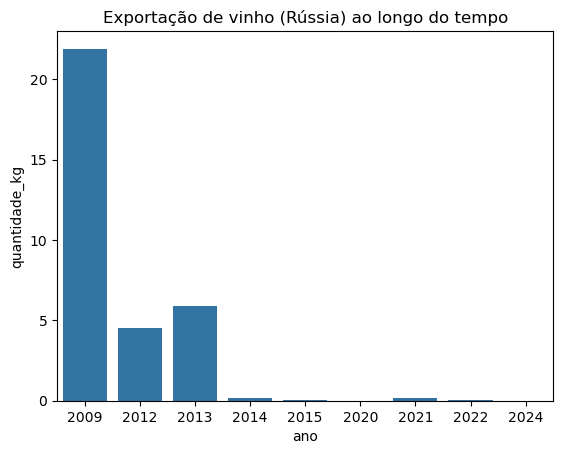

In [7]:
''' Durante o desenvolvimento foi identificado que alguns paises não há uma 
recorrencia de compra (exmplo: Rússia) e por isso foi criar uma função para manter apenas os país com recorrencia de compra '''

filtro_pais = "Rússia"

df_vinhos_ultimo_filtro_pais = df_vinhos_ultimo[df_vinhos_ultimo['pais'] == filtro_pais].copy()
df_vinhos_ultimo_filtro_pais['quantidade_kg'] = df_vinhos_ultimo_filtro_pais['quantidade_kg']/ (10**6)

sns.barplot(data=df_vinhos_ultimo_filtro_pais, x='ano', y='quantidade_kg')
plt.title(f'Exportação de vinho ({filtro_pais}) ao longo do tempo')
plt.grid(False)
plt.show()


In [8]:
# Verificar paises que existe uma recorrencia de compra 
paises_validos = []

min_conseq = 15

for pais, grupo in df_vinhos_ultimo.groupby('pais'):
    sequencias = encontrar_sequencias_consecutivas(grupo['ano'].tolist(),min_conseq)
    if sequencias:
        paises_validos.append(pais)

# Filtrar DataFrame original com os países que têm sequência válida
df_vinhos_ultimo_filtro = df_vinhos_ultimo[df_vinhos_ultimo['pais'].isin(paises_validos)].copy()
df_vinhos_ultimo_filtro.sort_values(by="ano")

tipo,id,pais,ano,quantidade_kg,valor_usd
1744,32,China,2009,1553416,482400
7189,131,"Tcheca, República",2009,9269,43902
974,18,Bélgica,2009,125962,58764
644,12,Austrália,2009,1014,9195
2899,53,Estados Unidos,2009,372319,660066
...,...,...,...,...,...
2914,53,Estados Unidos,2024,310410,648724
1759,32,China,2024,34231,182595
5884,107,Paraguai,2024,3705268,5121857
4454,81,Japão,2024,29320,66956


In [9]:
# Agrupar os dados
df_vinhos_ultimo_rank = df_vinhos_ultimo_filtro.copy()
df_vinhos_ultimo_rank = df_vinhos_ultimo_rank.groupby('pais')[['quantidade_kg','valor_usd']].sum().reset_index()

# Fazer o ranking
rank = 5
df_vinhos_ultimo_rank['ranking'] = df_vinhos_ultimo_rank['quantidade_kg'].rank(ascending=False, method='max')
df_vinhos_ultimo_rank = df_vinhos_ultimo_rank.query('ranking <= @rank').sort_values(by='ranking')
df_vinhos_ultimo_rank

tipo,pais,quantidade_kg,valor_usd,ranking
6,Paraguai,34508515,47984063,1.0
4,Estados Unidos,3659709,9957775,2.0
3,China,2608917,5086290,3.0
7,Reino Unido,1165560,4747648,4.0
5,Japão,1001661,2324119,5.0


In [10]:
# Calcular o preço médio e a elasticidade do preço pela quantidade

# Criar uma novo data frame com base 
df_vinhos_pm =  df_vinhos_ultimo_filtro.copy()

# Fazer o filtro dos paises do ranking
df_vinhos_pm = df_vinhos_pm[df_vinhos_pm['pais'].isin(df_vinhos_ultimo_rank['pais'])]

# Ordernar os dados
df_vinhos_pm = df_vinhos_pm.sort_values(by=['pais','ano'])

# Calcular o preço médio 
df_vinhos_pm['pm'] = (df_vinhos_pm['valor_usd'] / df_vinhos_pm['quantidade_kg'])

# Calcular a variação da quantidade e do preço 
df_vinhos_pm['var_pct_qtd'] = df_vinhos_pm.groupby('pais')['quantidade_kg'].pct_change() # Calcular a variação
df_vinhos_pm['var_pct_pm'] = df_vinhos_pm.groupby('pais')['pm'].pct_change() # Calcular a variação

# Calcular a Elasticidade do preço em relação à quantidade
df_vinhos_pm["elasticidade"] = abs((df_vinhos_pm["var_pct_pm"] / df_vinhos_pm["var_pct_qtd"]))

df_vinhos_pm = df_vinhos_pm.dropna()

# Criar a coluna do tipo de elasticidade

# Condições
condicoes = [
    df_vinhos_pm["elasticidade"].abs() > 1,
    df_vinhos_pm["elasticidade"].abs() < 1,
    df_vinhos_pm["elasticidade"].abs() == 1
]

# Valores associados às condições
tipos = [
    "Elástica (preço varia muito com a quantidade)",
    "Inelástica (preço varia pouco com a quantidade)",
    "Elasticidade unitária (variação proporcional)"
]

# Criar a coluna
df_vinhos_pm["tipo_elasticidade"] = np.select(condicoes, tipos, default="Não definido")
df_vinhos_pm.query('pais == "Estados Unidos"')

tipo,id,pais,ano,quantidade_kg,valor_usd,pm,var_pct_qtd,var_pct_pm,elasticidade,tipo_elasticidade
2900,53,Estados Unidos,2010,228968,478630,2.090379,-0.385022,0.179106,0.465185,Inelástica (preço varia pouco com a quantidade)
2901,53,Estados Unidos,2011,306787,1030254,3.358206,0.339868,0.606506,1.784530,Elástica (preço varia muito com a quantidade)
2902,53,Estados Unidos,2012,146585,303986,2.073787,-0.522193,-0.382472,0.732434,Inelástica (preço varia pouco com a quantidade)
2903,53,Estados Unidos,2013,245368,786556,3.205618,0.673896,0.545780,0.809888,Inelástica (preço varia pouco com a quantidade)
2904,53,Estados Unidos,2014,222267,494216,2.223524,-0.094148,-0.306366,3.254081,Elástica (preço varia muito com a quantidade)
2905,53,Estados Unidos,2015,195896,524109,2.675445,-0.118646,0.203245,1.713047,Elástica (preço varia muito com a quantidade)
2906,53,Estados Unidos,2016,258072,687411,2.663640,0.317393,-0.004412,0.013902,Inelástica (preço varia pouco com a quantidade)
2907,53,Estados Unidos,2017,132688,1523699,11.483322,-0.485849,3.311138,6.815160,Elástica (preço varia muito com a quantidade)
2908,53,Estados Unidos,2018,169109,512519,3.030702,0.274486,-0.736078,2.681659,Elástica (preço varia muito com a quantidade)
2909,53,Estados Unidos,2019,209765,616274,2.937926,0.240413,-0.030612,0.127332,Inelástica (preço varia pouco com a quantidade)


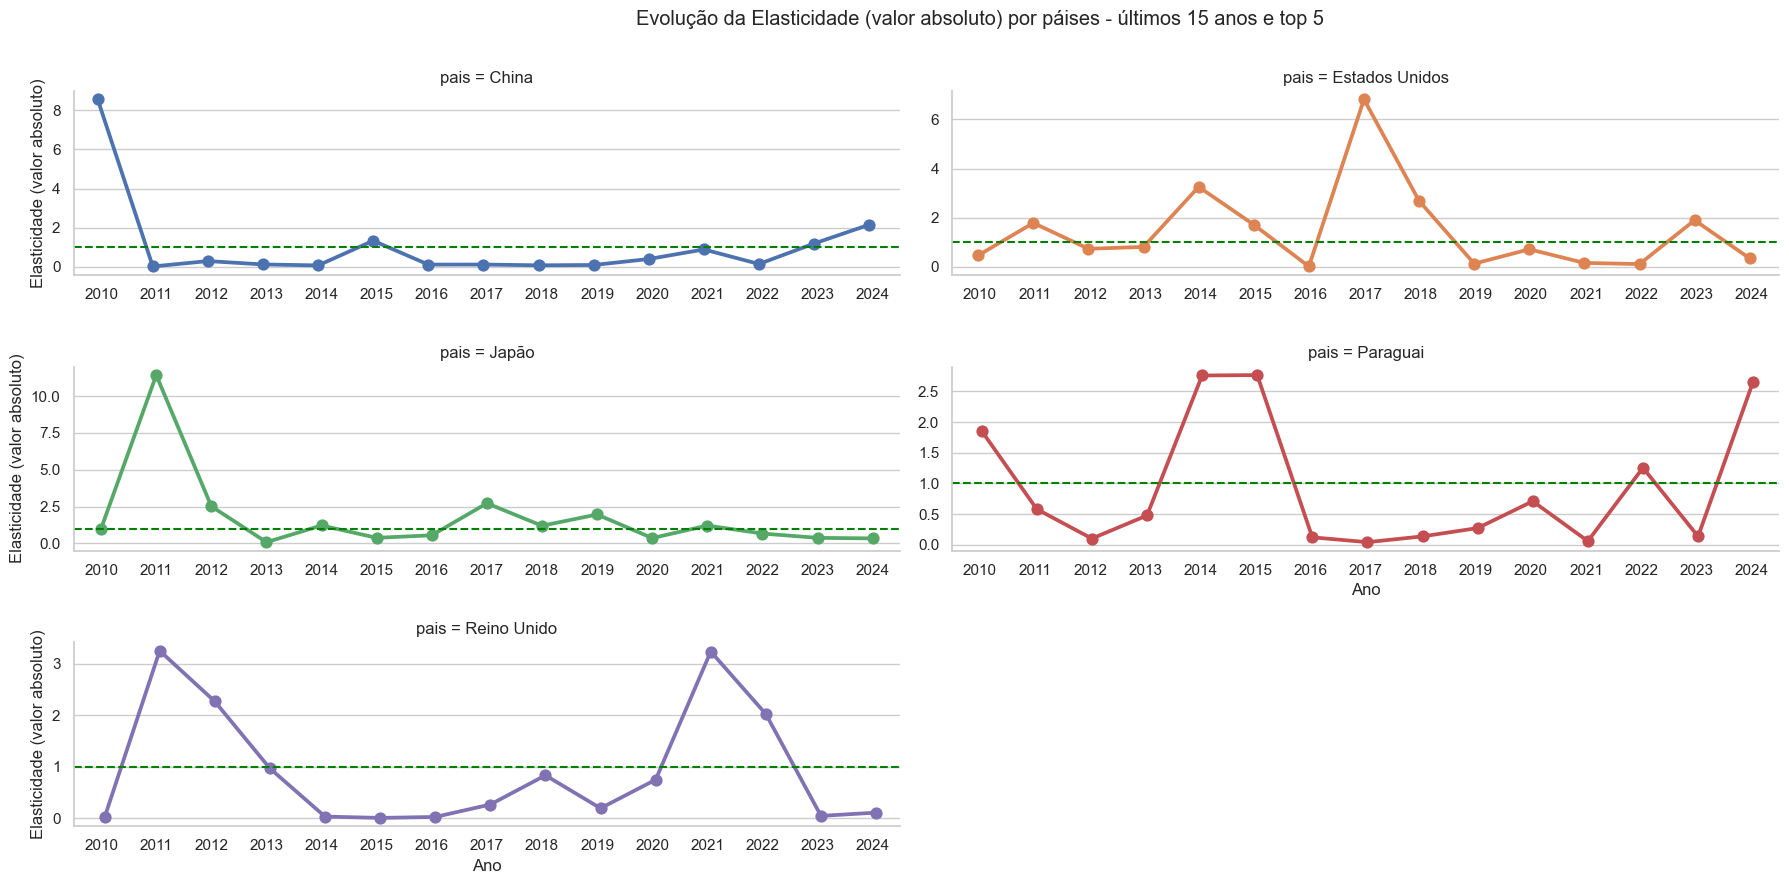

,Elasticidade (|E|),Classificação,Interpretação
0,E > 1,Elástica,Preço varia muito em relação à quantidade
1,E < 1,Inelástica,Preço varia pouco em relação à quantidade
2,E = 1,Elasticidade unitária,Variação proporcional entre preço e quantidade


In [11]:
# Definir o tema
sns.set_theme(style="whitegrid")

# Gerar o gráfico com catplot
g = sns.catplot(
    data=df_vinhos_pm,
    x='ano',
    y='elasticidade',
    hue='pais',
    col='pais',
    kind='point',
    height=3,      
    aspect=3,      
    markers='o',
    dodge=True,
    col_wrap=2,
    sharex=False,    
    sharey=False
)

# Adiciona linha horizontal para Elasticidade = 1
for ax in g.axes.flat:
    ax.axhline(1, color='green', linestyle='--', label='Elasticidade = 1')

# Título geral e ajuste de espaçamento
g.fig.subplots_adjust(top=0.89, hspace=0.5)
g.fig.suptitle(f'Evolução da Elasticidade (valor absoluto) por páises - últimos {delta_anos-1} anos e top {rank}')
g.set_axis_labels("Ano", "Elasticidade (valor absoluto)")
g._legend.remove()

plt.show()

# Criar DataFrame para interpretação
elasticidade = pd.DataFrame({
    "Elasticidade (|E|)": ["E > 1", "E < 1", "E = 1"],
    "Classificação": ["Elástica", "Inelástica", "Elasticidade unitária"],
    "Interpretação": [
        "Preço varia muito em relação à quantidade",
        "Preço varia pouco em relação à quantidade",
        "Variação proporcional entre preço e quantidade"
    ]
})

# Exibe a tabela
display(elasticidade)


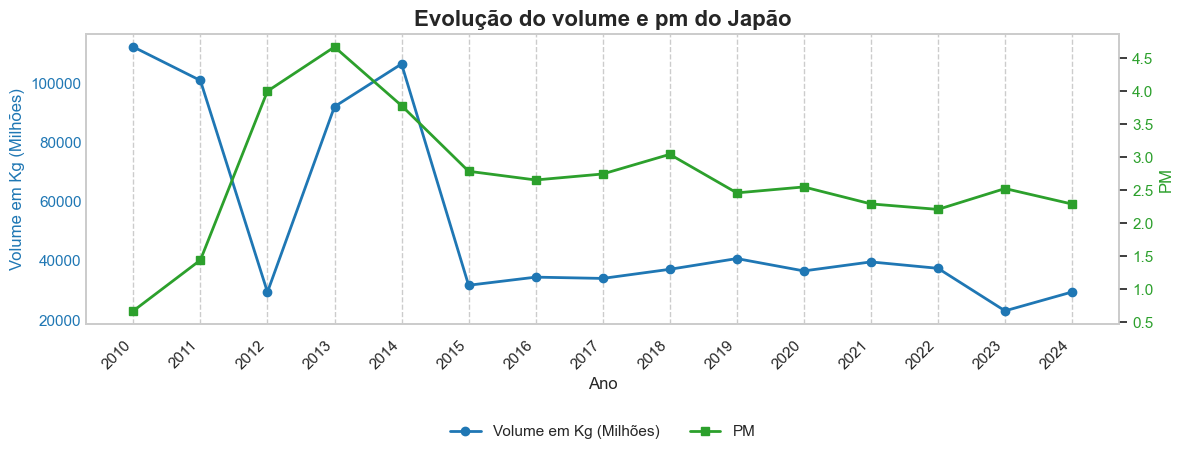

In [51]:
# Fazer o filtro dos paises
pais_filtro = ['Japão']

# Criar data frame com filtrado
df_vinhos_pm_filtro_pais = df_vinhos_pm.query('pais in @pais_filtro')

# Criar vizualização
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eixo Y da esquerda – Volume
color1 = 'tab:blue'
ax1.set_xlabel("Ano", fontsize=12)
ax1.set_ylabel("Volume em Kg (Milhões)", color=color1, fontsize=12)

vol_anos = df_vinhos_pm_filtro_pais["ano"]
vol_valores = df_vinhos_pm_filtro_pais["quantidade_kg"]
ax1.plot(vol_anos, vol_valores, marker='o', color=color1, label="Volume em Kg (Milhões)", linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(vol_anos)
ax1.set_xticklabels(vol_anos, rotation=45, ha='right')

# Eixo Y da direita – Valor
ax2 = ax1.twinx()
color2 = 'tab:green'
val_anos = df_vinhos_pm_filtro_pais["ano"]
val_valores = df_vinhos_pm_filtro_pais["pm"]
ax2.set_ylabel("PM", color=color2, fontsize=12)
ax2.plot(val_anos, val_valores, marker='s', color=color2, label="PM", linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Titulo do Grafico
plt.title(f"Evolução do volume e pm do {pais_filtro[0]}", fontsize=16, weight='bold')

# Remover grade
ax1.grid(False)
ax2.grid(False)
ax1.yaxis.grid(False)
ax1.tick_params(axis='y', which='both', length=0)
ax1.grid(True, axis='x', linestyle="--", alpha=1)

# Inserir legenda na parte inferior
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

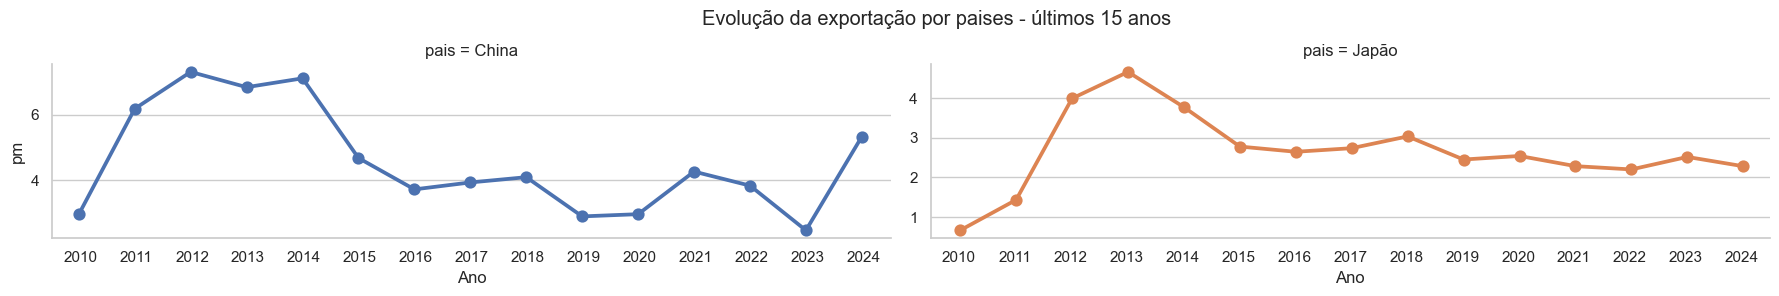

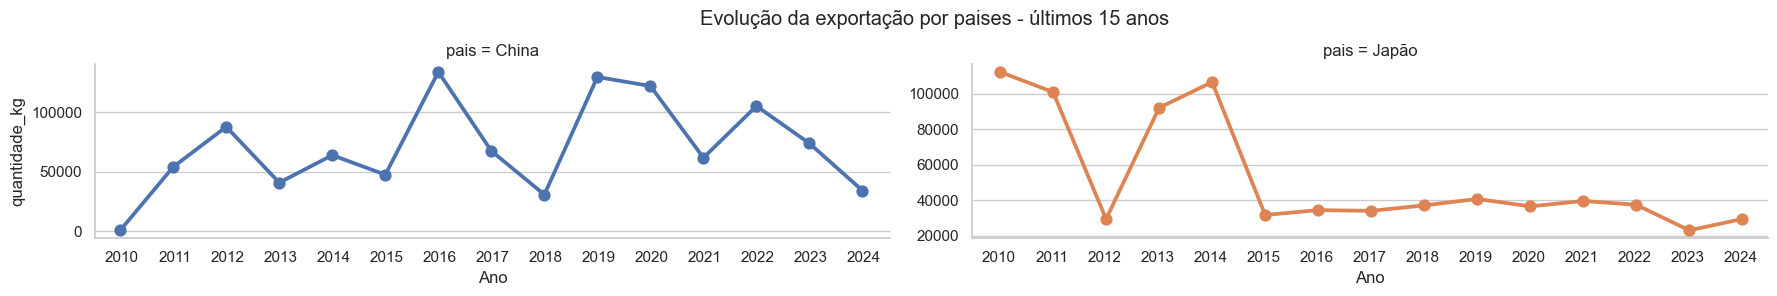

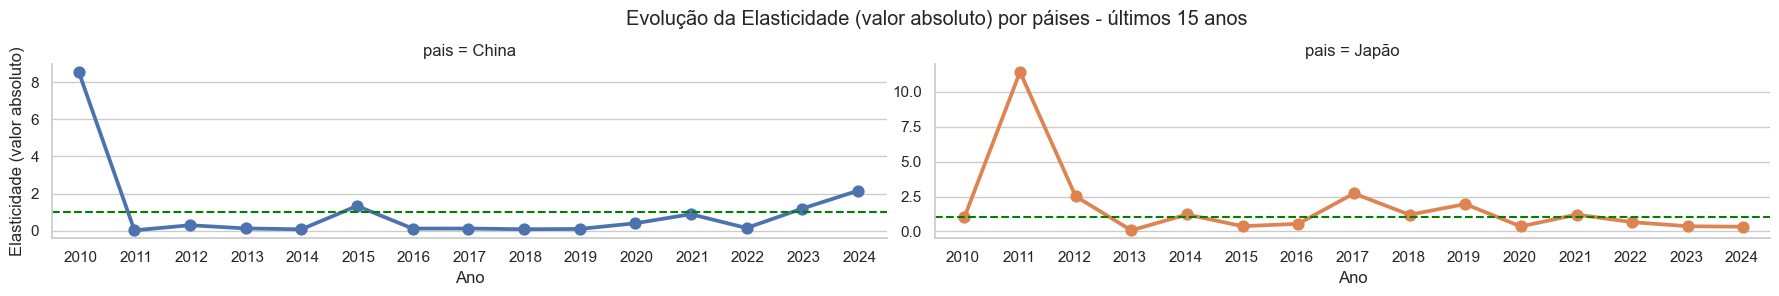

tipo,pais,ano,quantidade_kg,pm,var_pct_qtd,var_pct_pm,elasticidade,tipo_elasticidade
1745,China,2010,795,2.966038,-0.999488,8.551183,8.555561,Elástica (preço varia muito com a quantidade)
1746,China,2011,54156,6.183378,67.120755,1.084727,0.016161,Inelástica (preço varia pouco com a quantidade)
1747,China,2012,87905,7.305352,0.623181,0.181450,0.291168,Inelástica (preço varia pouco com a quantidade)
1748,China,2013,40929,6.840040,-0.534395,-0.063695,0.119190,Inelástica (preço varia pouco com a quantidade)
1749,China,2014,64040,7.110244,0.564661,0.039503,0.069959,Inelástica (preço varia pouco com a quantidade)
1750,China,2015,47609,4.681174,-0.256574,-0.341630,1.331505,Elástica (preço varia muito com a quantidade)
1751,China,2016,134106,3.725575,1.816820,-0.204137,0.112359,Inelástica (preço varia pouco com a quantidade)
1752,China,2017,67594,3.936533,-0.495966,0.056624,0.114169,Inelástica (preço varia pouco com a quantidade)
1753,China,2018,30835,4.097162,-0.543820,0.040805,0.075034,Inelástica (preço varia pouco com a quantidade)
1754,China,2019,129852,2.901981,3.211189,-0.291710,0.090842,Inelástica (preço varia pouco com a quantidade)


In [13]:
# Definir o tema
sns.set_theme(style="whitegrid")

# Fazer o filtro dos paises
pais_filtro = ['China','Japão']

# Criar data frame com filtrado
df_vinhos_pm_filtro_pais = df_vinhos_pm.query('pais in @pais_filtro')

# Gerar o gráfico com catplot - pm
g = sns.catplot(
    data=df_vinhos_pm_filtro_pais,
    x='ano',
    y='pm',
    hue='pais',
    col='pais',
    kind='point',
    height=3,      
    aspect=3,      
    markers='o',
    dodge=True,
    col_wrap=2,
    sharex=False,    
    sharey=False
)

# Título geral e ajuste de espaçamento
g.fig.subplots_adjust(top=0.8, hspace=0.5)
g.fig.suptitle(f'Evolução da exportação por paises - últimos {delta_anos-1} anos')
g.set_axis_labels("Ano", "pm")
g._legend.remove()

# Gerar o gráfico com catplot - qtd
g = sns.catplot(
    data=df_vinhos_pm_filtro_pais,
    x='ano',
    y='quantidade_kg',
    hue='pais',
    col='pais',
    kind='point',
    height=3,      
    aspect=3,      
    markers='o',
    dodge=True,
    col_wrap=2,
    sharex=False,    
    sharey=False
)

# Título geral e ajuste de espaçamento
g.fig.subplots_adjust(top=0.8, hspace=0.5)
g.fig.suptitle(f'Evolução da exportação por paises - últimos {delta_anos-1} anos')
g.set_axis_labels("Ano", "quantidade_kg")
g._legend.remove()

# Gerar o gráfico com catplot - elasticidade
g = sns.catplot(
    data=df_vinhos_pm_filtro_pais,
    x='ano',
    y='elasticidade',
    hue='pais',
    col='pais',
    kind='point',
    height=3,      
    aspect=3,      
    markers='o',
    dodge=True,
    col_wrap=2,
    sharex=False,    
    sharey=False
)

# Adiciona linha horizontal para Elasticidade = 1
for ax in g.axes.flat:
    ax.axhline(1, color='green', linestyle='--', label='Elasticidade = 1')

# Título geral e ajuste de espaçamento
g.fig.subplots_adjust(top=0.8, hspace=0.5)
g.fig.suptitle(f'Evolução da Elasticidade (valor absoluto) por páises - últimos {delta_anos-1} anos')
g.set_axis_labels("Ano", "Elasticidade (valor absoluto)")
g._legend.remove()

plt.show()

display(df_vinhos_pm_filtro_pais[['pais','ano','quantidade_kg','pm','var_pct_qtd','var_pct_pm','elasticidade','tipo_elasticidade']].sort_values(by=['pais','ano']))

tipo,pais,valor_usd,ranking,valor_usd_m
4,Estados Unidos,9297709,1.0,9.297709
6,Reino Unido,4678860,2.0,4.678860
3,China,4603890,3.0,4.603890
5,Japão,2040683,4.0,2.040683
0,"Alemanha, República Democrática",1802890,5.0,1.802890
2,Bélgica,1332510,6.0,1.332510
1,Austrália,393490,7.0,0.393490
7,"Tcheca, República",272105,8.0,0.272105


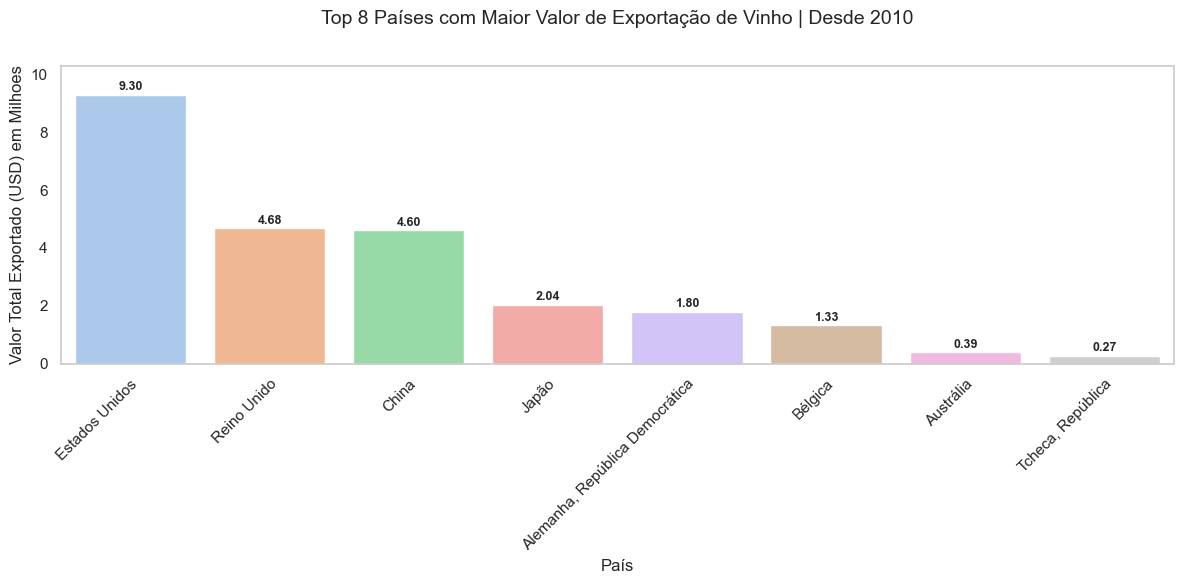

In [14]:
# O df_vinhos_tratado é o data frame princiapl

# Limitar os ultimos anos qtd maior que zero
delta_anos = 15
ano_atual = datetime.now().year
limite = ano_atual-delta_anos

df_vinhos_ultimo_pais = df_vinhos_tratado.copy()
df_vinhos_ultimo_pais = df_vinhos_ultimo[(df_vinhos_ultimo['ano'] >=  limite) & (df_vinhos_ultimo['quantidade_kg'] > 0)]

# Verificar paises que existe uma recorrencia de compra 
paises_validos = []

min_conseq = 15

for pais, grupo in df_vinhos_ultimo_pais.groupby('pais'):
    sequencias = encontrar_sequencias_consecutivas(grupo['ano'].tolist(),min_conseq)
    if sequencias:
        paises_validos.append(pais)

# Paraguai é o principal pais e removemos eles para não distorce muito a analise 
paises_validos.remove('Paraguai')

# Filtrar DataFrame com os países que têm sequência válida
df_vinhos_ultimo_pais = df_vinhos_ultimo_pais[df_vinhos_ultimo_pais['pais'].isin(paises_validos)]

# Agrupar os dados e fazer o ranking
rank = 10
df_vinhos_ultimo_pais = df_vinhos_ultimo_pais.groupby('pais')[['valor_usd']].sum().reset_index()
df_vinhos_ultimo_pais['ranking'] = df_vinhos_ultimo_pais['valor_usd'].rank(ascending=False, method='max')
df_vinhos_ultimo_pais = df_vinhos_ultimo_pais.query('ranking <= @rank').sort_values(by='ranking')
df_vinhos_ultimo_pais['valor_usd_m'] = df_vinhos_ultimo_pais['valor_usd'] / (10**6)
display(df_vinhos_ultimo_pais.sort_values(by='ranking'))

# Definir o estilo e paleta de cores
sns.set_theme(style="whitegrid")
palette = sns.color_palette("pastel",n_colors=len(df_vinhos_ultimo_pais))

# Criar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="pais", 
    y="valor_usd_m", 
    hue = 'pais',
    data=df_vinhos_ultimo_pais, 
    palette=palette
)

max_y = df_vinhos_ultimo_pais['valor_usd_m'].max()
ax.set_ylim(0, max_y + 1)  # sobe 1 unidade além do maior valor

# Adicionar rótulos em cima das barras
for i, v in enumerate(df_vinhos_ultimo_pais["valor_usd_m"]):
    ax.text(i, v + 0.05, f"{v:.2f}",  # valor formatado com 2 decimais
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
# Título e rótulos
plt.title(f"Top {len(df_vinhos_ultimo_pais)} Países com Maior Valor de Exportação de Vinho | Desde {limite}", fontsize=14,pad=30)
plt.ylabel("Valor Total Exportado (USD) em Milhoes")
plt.xlabel("País")
plt.xticks(rotation=45, ha='right', va="top",rotation_mode='anchor')
plt.grid(False)

plt.tight_layout()
plt.show()